In [1]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [2]:
# IN_syn_pairs = ['G140S-Q148H', 'Y143C-S230R']
# PR_syn_pairs = ['D30N-N88D', 'V32I-I47V']
# RT_syn_pairs = ['K101E-G190S', 'K103N-P225H']

IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')


# # Convert synergistic pairs to reduced format
# IN_syn_pairs_reduced = functions.pairs_to_reduced(IN_redux, IN_syn_pairs)
# PR_syn_pairs_reduced = functions.pairs_to_reduced(PR_redux, PR_syn_pairs)
# RT_syn_pairs_reduced = functions.pairs_to_reduced(RT_redux, RT_syn_pairs)

# print("IN reduced pairs:", IN_syn_pairs_reduced)
# print("PR reduced pairs:", PR_syn_pairs_reduced)
# print("RT reduced pairs:", RT_syn_pairs_reduced)

IN pairs:
G140S-Q148H
Y143C-S230R

Y143R-N155H
Y148H-N155H

RT:
F116Y-Q151M
K101E-G190A

L100I-Y181C
K65R-T215Y

PR:
D30N-N88D
V32I-I47V
I50V-I84V
V82A-I84V

In [3]:
# IN_pairs = ['G140S-Q148H', 'Y143C-S230R', 'Y143R-N155H', 'Y148H-N155H']
IN_pairs = ['G140S-Q148H', 'Y143C-S230R', 'Y143R-N155H']
RT_pairs = ['F116Y-Q151M', 'K101E-G190A', 'L100I-Y181C', 'K65R-T215Y']
PR_pairs = ['D30N-N88D', 'V32I-I47V', 'I50V-I84V', 'V82A-I84V']


G140S Q148H C140D D148B
ABAAABCBACABAACBDBABBDBDBBBAAACAABAAABDAABAABAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCAAAABABAAAABDCBCAAADABCCCDDAAAAAAAABDBDACBADAAABDABAAAAACBBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABBAABBBBCACDCAACDBDCCCAAAAABADDBCACAAAAABAABAAAAAAABBDBDBACCBBBA
IN Pair: G140S-Q148H, ΔE1: -5.7286787033081055, ΔE2: -4.553504943847656, ΔΔE: -1.7733993530273438
Y143C S230R D143A D230C
ABAAABCBACABAACBDBABBDBDBBBAAACAABAAABDAABAABAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCAAAABABAAAABDCBCAAADABCCCDDAAAAAAAABDBDACBADAAABDABAAAAACBBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABBAABBBBCACDCAACDBDCCCAAAAABADDBCACAAAAABAABAAAAAAABBDBDBACCBBBA
IN Pair: Y143C-S230R, ΔE1: -6.36799430847168, ΔE2: -5.990548610687256, ΔΔE: -5.981003761291504
Y143R N155H D143C A155C
ABAAABCBACABAACBDBABBDBDBBBAAACAABAAABDAABAABAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCAAAABABAAAABDCBCAAADABCCCDDAAAAAAAABDBDACBADAAABDABAAAAACBBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABBAABBBB

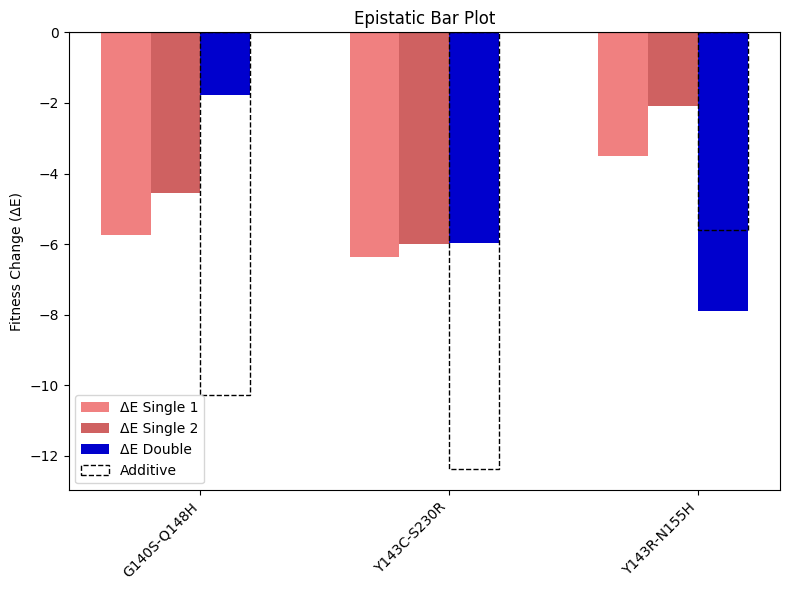

In [4]:
IN_bars = []
for IN_pair in IN_pairs:
    pair1, pair2 = functions.split_pairs(IN_pair)
    p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
    p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)
    print(pair1, pair2,p1_reduced,p2_reduced)
    print(IN_consensus_seq)
    pair1_de,pair2_de, pair12_de, pair12_dde = functions.calculate_delta_delta_e(p1_reduced,p2_reduced,IN_consensus_seq,IN_J,1,263)
    print(f"IN Pair: {IN_pair}, ΔE1: {pair1_de}, ΔE2: {pair2_de}, ΔΔE: {pair12_de}")
    IN_bars.append((IN_pair,pair1_de,pair2_de,pair12_de))
plot.plot_epistatic_bar(IN_bars)

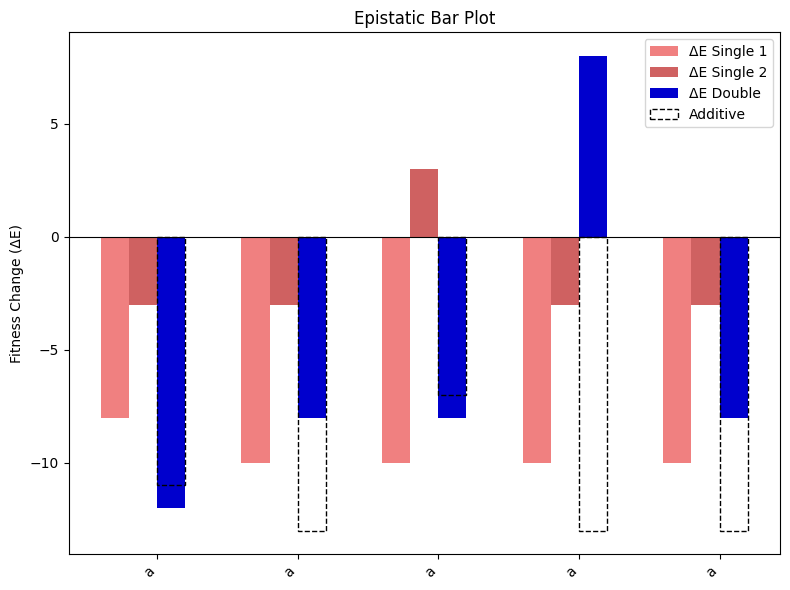

In [5]:
plot.plot_epistatic_bar([('a',-8,-3,-12), ('a',-10,-3,-8),('a',-10,3,-8), ('a',-10,-3,8), ('a',-10,-3,-8)])